# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Conexión a la base de Datos
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_rtp', 97052261)

In [4]:
amin = conn.get(r'\top.zerod:amin').data()
rmag = conn.get(r'\top.zerod:amin').data()

In [5]:
# Obtención de los perfiles T y n como F(r,t)

Te = conn.get(r'\top.twod:te').data()
ne = conn.get(r'\top.twod:ne').data()

In [6]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
r = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [7]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:te)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [8]:
assert Te.shape == (len(t), len(r)), f"Unexpected Te shape: {Te.shape}, t={len(t)}, r={len(r)}"
assert ne.shape == (len(t), len(r)), f"Unexpected Te shape: {ne.shape}, t={len(t)}, r={len(r)}"

AssertionError: Unexpected Te shape: (40,), t=1, r=40

In [9]:
t0 = 9.6
itime = np.argmin(np.abs(t - t0))

In [10]:
Te_r = Te[itime, :]
ne_r = ne[itime, :]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

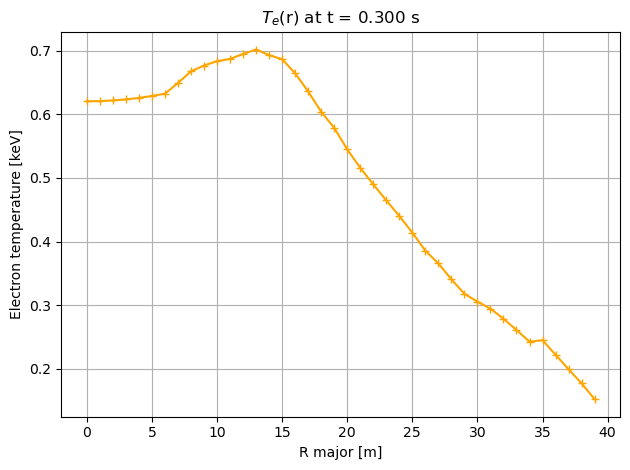

In [13]:
plt.figure()
plt.plot(Te, marker='+', linestyle='-', color='orange')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron temperature [{Te_unit}]")
plt.title(rf"$T_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()

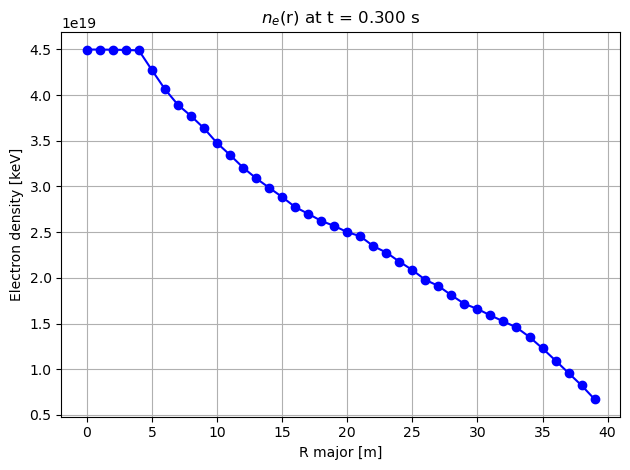

In [14]:
plt.figure()
plt.plot(ne, marker='o', linestyle='-', color='blue')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron density [{ne_unit}]")
plt.title(rf"$n_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()